In [2]:
# Importamos librerías necesarias.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Activation, Layer, Input

import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Modificamos las funciones de keras, en específico de la clase Layer.
class Color_a_EscalaGrises(Layer):
    """
    Convierte imágenes RGB a escala de grises usando promedio simple,
    es decir:
    Y = (R + G + B) / 3
    """
    # Llamamos al constructor y lo dejamos igual.
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        # Aseguramos nùmeros flotantes.
        x = tf.cast(inputs, tf.float32)
        # Promedio sobre el canal de color.
        gris = tf.reduce_mean(x, axis=-1, keepdims=True)
        return gris

    def get_config(self):
        return super().get_config()

In [5]:
ruta_imagen = "/content/drive/MyDrive/Redes neuronales/Kirby.jpg"

# Cargamos la imagen en un tensor.
img = tf.io.read_file(ruta_imagen)
# Para asegurar que la imagen sea RGB:
img = tf.image.decode_image(img, channels=3)
# Y normalizamos de [0, 1].
img = tf.image.convert_image_dtype(img, tf.float32)
# Mostramos el tamaño de la imagen.
print("Shape original:", img.shape)
# El primero es altura, luego ancho y finalmente los canales.

Shape original: (2160, 3840, 3)


In [6]:
# Expandimos dimensiones a (1, H, W, 3).
img_batch = tf.expand_dims(img, axis=0)
# Creamos la capa.
capa_grises = Color_a_EscalaGrises()
# Aplicamos la capa.
img_gris = capa_grises(img_batch)
print("Shape en gris:", img_gris.shape)

Shape en gris: (1, 2160, 3840, 1)


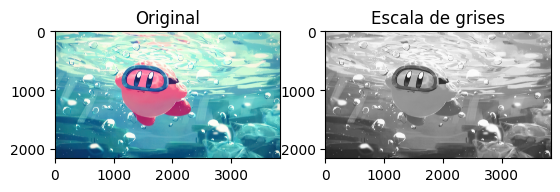

In [7]:
# Visualizamos la imagen original.
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img.numpy())

# Visualizamos la imagen después de pasar por la capa creada.
plt.subplot(1,2,2)
plt.title("Escala de grises")
plt.imshow(tf.squeeze(img_gris.numpy()), cmap="gray")
plt.show()